# Exploracion: el motor de extremo a extremo

Recorre el motor completo sobre un activo del fixture, en el mismo orden en que lo
hara la interfaz: **datos -> descriptivos -> modelo -> trayectoria -> niveles ->
validacion -> puerta**, y cierra comparando los veinte activos entre si.

Sirve para tres cosas:

1. Ejercitar cada funcion de `src/` contra datos conocidos.
2. Ver escrita la cadena de llamadas que sera el orquestador de la interfaz.
3. Reproducir los casos del oraculo sin depender de scripts sueltos.

Su cuaderno hermano, `datos_reales.ipynb`, prueba lo que el fixture sintetico no
puede: la descarga de yfinance, la cobertura con huecos, el alineado y el
remuestreo.

In [1]:
import numpy as np
import pandas as pd

import src.contracts as ct
import src.data as dt
import src.analytics as ana
import src.forecasting as fc
import src.risk_rules as rr
import src.pipeline as pl

FIXTURE = "notebooks/Fixture_20_activos_sintetico_TBS_EIA.csv"
TICKER = "AAPL"
H = 20

params = ct.Params()
M = dt.PERIODOS_POR_ANIO["D"]
params

Params(p_L=0.05, p_U=0.95, BR_min=1.0, cost_buy=0.0, cost_sell=0.0, confidence=0.95, capital=10000.0)

## 1. Datos

`load_fixture` es el punto de entrada real: encadena `wide_from_long` y
`validate_prices`, asi que devuelve la matriz ancha ya ordenada y sin precios no
positivos. La interfaz llamara a esta funcion o a `fetch_prices`, nunca a
`pd.read_csv` directamente.

In [2]:
precios = dt.load_fixture(FIXTURE)
print(precios.shape, "->", len(precios), "fechas x", precios.shape[1], "tickers")
precios.tail(3)

(540, 20) -> 540 fechas x 20 tickers


,AAPL,AMZN,CAT,COST,GOOGL,HD,JNJ,JPM,KO,MA,MCD,META,MSFT,NVDA,PEP,PG,UNH,V,WMT,XOM
date,,,,,,,,,,,,,,,,,,,,
2026-08-11,72.629015,92.227004,205.852188,181.549116,100.828855,170.764422,125.030454,114.611744,139.800313,194.725886,218.752425,107.349546,82.617822,105.704768,149.785884,143.838316,174.681358,184.226094,159.553703,134.573597
2026-08-12,73.129873,92.380593,207.217265,180.928882,100.446259,171.101181,124.796927,114.314249,140.424150,194.288823,218.539700,106.793935,83.141223,105.248214,150.995817,143.913998,173.551424,183.461941,160.544614,134.413657
2026-08-13,73.633371,92.291030,208.104938,179.507666,99.818889,170.236645,124.954236,115.201589,141.232400,194.990677,219.408351,106.196373,83.547993,104.918758,151.796213,144.405483,172.564608,183.526573,160.645374,134.599161


`coverage` resume cada columna antes de alinear: primera fecha, ultima, cuantas
observaciones y que porcentaje falta. Es el filtro que decide que activos entran.

In [3]:
dt.coverage(precios)

,start,end,n,missing_pct
AAPL,2024-07-19,2026-08-13,540,0.0
AMZN,2024-07-19,2026-08-13,540,0.0
CAT,2024-07-19,2026-08-13,540,0.0
COST,2024-07-19,2026-08-13,540,0.0
GOOGL,2024-07-19,2026-08-13,540,0.0
HD,2024-07-19,2026-08-13,540,0.0
JNJ,2024-07-19,2026-08-13,540,0.0
JPM,2024-07-19,2026-08-13,540,0.0
KO,2024-07-19,2026-08-13,540,0.0
MA,2024-07-19,2026-08-13,540,0.0


## 2. Log-rendimientos

Unica convencion admitida: $g_t = ln(P_t / P_{t-1})$. El primer valor se pierde,
por eso hay una observacion menos que precios.

In [4]:
serie = precios[TICKER].dropna()
g = ana.log_returns(serie)
P_t = serie.iloc[-1]

print(f"{len(serie)} precios -> {len(g)} rendimientos")
print(f"P_t = {P_t:.4f}")

540 precios -> 539 rendimientos
P_t = 73.6334


## 3. Descriptivos

`descriptives` devuelve dos bloques con las mismas quince metricas: la **muestra
completa** y un sub-bloque `recent` con las ultimas `m` observaciones, es decir el
ultimo anio.

Recent sirve para comparar por ejemplo si la volatilidad reciente se despega de la historica, el
activo cambio de regimen y el modelo, que se ajusta sobre **toda** la serie,
esta promediando dos comportamientos distintos y subestimando el riesgo de hoy.

In [5]:
d = ana.descriptives(g, M)
claves = ["n", "mean_period", "sd_period", "mean_annual", "sd_annual",
          "median", "min", "p25", "p75", "max", "q05", "q95", "skew", "kurtosis"]

pd.DataFrame({"muestra": {k: d[k] for k in claves},
              "reciente": {k: d["recent"][k] for k in claves}})

,muestra,reciente
n,539.000000,252.000000
mean_period,0.000094,0.000098
sd_period,0.004169,0.004254
mean_annual,0.023659,0.024786
sd_annual,0.066184,0.067530
median,0.000112,0.000075
min,-0.013380,-0.013380
p25,-0.003218,-0.003065
p75,0.003521,0.003511
max,0.014020,0.014020


El drawdown se calcula sobre **precios**, no sobre rendimientos:
`P_t / cummax(P) - 1`.

drawdown maximo: -7.0246%


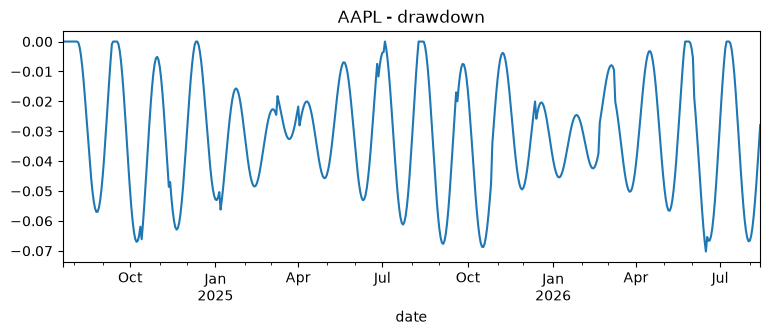

In [6]:
dd, dd_max = ana.drawdown(serie)
print(f"drawdown maximo: {dd_max:.4%}")
dd.plot(figsize=(9, 3), title=f"{TICKER} - drawdown");

## 4. Diagnosticos

Cuatro contrastes, cada uno sobre un supuesto distinto del modelo lognormal. Todos
devuelven estadistico, p-valor y un `reject` ya resuelto contra `alpha`: ese
booleano es lo unico que la puerta lee.

| contraste | que pregunta | si rechaza |
|---|---|---|
| **Jarque-Bera** | son normales? | los cuantiles quedan mal calculados: `SL`, `TP` y el VaR salen de `norm.ppf`. Con colas gruesas el VaR **subestima** el riesgo extremo |
| **Ljung-Box** | son independientes? | hay memoria en la serie y $v = h\sigma^2$ deja de valer: la varianza real a `H` periodos es mayor, y los intervalos salen demasiado estrechos |
| **Brown-Forsythe** | la varianza es estable? | la volatilidad cambio a lo largo del periodo; el $\sigma$ unico que estima `fit` promedia regimenes distintos |
| **ARCH-LM** | la volatilidad se agrupa? | los dias agitados vienen seguidos, en las rachas turbulentas los intervalos se quedan cortos y en las tranquilas sobran |

Ljung-Box mira el **signo** de los rendimientos; ARCH-LM mira su **tamaño**, porque
opera sobre los cuadrados centrados. Una serie puede pasar el primero y fallar el
segundo.

Brown-Forsythe parte la muestra en tres bloques cronologicos y compara sus
dispersiones usando la **mediana** como centro, que es lo que lo hace robusto a
valores extremos.

Ninguno de los cuatro bloquea la senial. Todos dicen lo mismo con distinta
evidencia —"el modelo es una aproximacion, no la verdad"— y por eso `signal_gate`
los convierte en advertencias y en la etiqueta `condicional`, nunca en un rechazo.

In [7]:
diag = ana.diagnostics(g)

pd.DataFrame({k: {"estadistico": diag[k]["statistic"],
                  "p-valor": diag[k]["pvalue"],
                  "rechaza": diag[k]["reject"]}
              for k in ("jarque_bera", "ljung_box", "brown_forsythe", "arch_lm")}).T

,estadistico,p-valor,rechaza
jarque_bera,11.927529,0.00257,True
ljung_box,1524.302951,0.0,True
brown_forsythe,0.765866,0.465439,False
arch_lm,216.128896,0.0,True


## 5. Modelo y momentos acumulados

El modelo **A** impone $\mu = 0$ (caminata sin deriva); el **B** estima la deriva de
la muestra. Los momentos escalan linealmente con el horizonte: $m = h\mu$ y
$v = h\sigma^2$  ojo que $v$ es **varianza**, no desviacion.

In [8]:
for modelo in ("A", "B"):
    mu_i, sigma_i = fc.fit(g, modelo)
    m_i, v_i = fc.cumulative_moments(mu_i, sigma_i, H)
    print(f"modelo {modelo}:  mu = {mu_i: .4f}  sigma = {sigma_i:.6f}"
          f"   ->  m_H = {m_i: .4f}  v_H = {v_i:.6f}")

mu, sigma = fc.fit(g, "B")
m_H, v_H = fc.cumulative_moments(mu, sigma, H)

modelo A:  mu =  0.0000  sigma = 0.004169   ->  m_H =  0.0000  v_H = 0.000348
modelo B:  mu =  0.0001  sigma = 0.004169   ->  m_H =  0.0019  v_H = 0.000348


## 6. Trayectoria

Con $\mu$ y $\sigma$ fijos, los momentos acumulados crecen de forma distinta: la
media escala con `h`, pero la desviacion lo hace con la **raiz** de `h`. Por eso
el intervalo se abre despacio y no en linea recta.

In [9]:
pd.DataFrame([
    {"h": h, "m": m_h, "v": v_h, "sd": np.sqrt(v_h), "sd/sd(h=1)": np.sqrt(v_h) / sigma}
    for h in (1, 4, 9, 16, H)
    for m_h, v_h in [fc.cumulative_moments(mu, sigma, h)]
])

,h,m,v,sd,sd/sd(h=1)
0,1,0.000094,0.000017,0.004169,1.000000
1,4,0.000376,0.000070,0.008338,2.000000
2,9,0.000845,0.000156,0.012508,3.000000
3,16,0.001502,0.000278,0.016677,4.000000
4,20,0.001878,0.000348,0.018645,4.472136


`terminal` da la foto en $t+H$: mediana, media y los dos cuantiles. La media
queda por encima de la mediana porque la lognormal es asimetrica, el factor
$e^{(v/2)}$ no aparece en la mediana.

In [10]:
fc.terminal(P_t, m_H, v_H, params)

{'median': np.float64(73.77175945267831),
 'mean': np.float64(73.78458358290783),
 'q_L': np.float64(71.54363288900151),
 'q_U': np.float64(76.06927790747508)}

`path` repite ese calculo para cada `h` de 1 a `H` y devuelve la pelicula
completa

In [11]:
trayectoria = fc.path(P_t, mu, sigma, H, params)
trayectoria["ancho_%"] = (trayectoria.q_U - trayectoria.q_L) / P_t * 100
trayectoria

,h,median,mean,q_L,q_U,ancho_%
0,1,73.640284,73.640924,73.137010,74.147021,1.371676
1,2,73.647198,73.648478,72.936403,74.364920,1.940040
2,3,73.654112,73.656033,72.784435,74.534181,2.376295
3,4,73.661028,73.663588,72.657637,74.678275,2.744189
4,5,73.667944,73.671145,72.546919,74.806291,3.068408
5,6,73.674860,73.678702,72.447619,74.922890,3.361615
6,7,73.681777,73.686260,72.356971,75.030840,3.631328
7,8,73.688695,73.693819,72.273168,75.131946,3.882448
8,9,73.695613,73.701378,72.194960,75.227460,4.118377
9,10,73.702533,73.708938,72.121433,75.318294,4.341592


## 7. Niveles, probabilidades y VaR

`levels` traduce los momentos a precios y les aplica las comisiones. `P_BE` es el
precio al que hay que vender para no perder nada, una vez pagadas las dos puntas.

In [12]:
niveles = rr.levels(P_t, m_H, v_H, params.p_L, params.p_U,
                    params.cost_buy, params.cost_sell)
pd.Series(niveles)

E          73.633371
SL         71.543633
TP         76.069278
P_BE       73.633371
D_neto      2.089738
U_neto      2.435907
BR_neto     1.165652
dtype: float64

In [13]:
probs = rr.terminal_probs(P_t, niveles["P_BE"], m_H, v_H)
frac, dinero = rr.var(m_H, v_H, params.confidence, params.capital)

print(f"Pr(ganar)   {probs['win']:.4%}")
print(f"Pr(perder)  {probs['lose']:.4%}")
print(f"VaR {params.confidence:.0%}   {frac:.4%}  ->  {dinero:,.2f} "f"sobre {params.capital:,.0f}")

Pr(ganar)   54.0108%
Pr(perder)  45.9892%
VaR 95%   2.8380%  ->  283.80 sobre 10,000


Contraste util para la sustentacion: el VaR parametrico supone normalidad de los
log-rendimientos. Comparado con el cuantil empirico acumulado a `H` periodos suele
quedarse **corto**, y eso es coherente con la cobertura que reporta el walk-forward.

In [14]:
acum = g.rolling(H).sum().dropna()
hist = max(0.0, 1 - np.exp(acum.quantile(1 - params.confidence)))
print(f"VaR parametrico {frac:.4%}   vs   VaR historico {hist:.4%}")

VaR parametrico 2.8380%   vs   VaR historico 5.2542%


## 8. Validacion temporal

`walk_forward` reajusta el modelo en diez origenes con ventana expansiva y compara
contra lo que realmente paso. `sufficient` dice si hubo historia bastante; el resto
son metricas de desempeno.

In [15]:
wf = fc.walk_forward(g, "B", H, M, params)
{k: wf[k] for k in wf if k != "origins"}

{'sufficient': True,
 'errors': array([-0.05437814, -0.06016848, -0.06347408, -0.06416956, -0.06223819,
        -0.05777207, -0.05096789, -0.04211816, -0.03159852, -0.01985159]),
 'mae': np.float64(0.05067366801044594),
 'rmse': np.float64(0.05263016345991737),
 'coverage': np.float64(0.1),
 'direction': np.float64(0.0),
 'direction_n': 10}

## 9. La puerta

Aqui se junta todo. Siete reglas de niveles y costos **bloquean**; los diagnosticos
y la insuficiencia de muestra solo **advierten** y etiquetan el pronostico. La
decision final es de quien opera.

In [16]:
puerta = rr.signal_gate(niveles, diag, wf["sufficient"], params.BR_min)

print("señal", puerta["signal"])
print("etiqueta", puerta["label"])
print("incumplidas", puerta["failed"] or "ninguna")
print("advertencias", puerta["warnings"] or "ninguna")

señal True
etiqueta condicional
incumplidas ninguna
advertencias ['jarque_bera', 'ljung_box', 'arch_lm']


## 10. Los veinte activos

`pipeline.analyze` encadena el motor completo sobre una serie y devuelve todo lo
que una vista puede necesitar: descriptivos, diagnosticos, niveles, VaR,
trayectoria, validacion temporal y la puerta.

El orden de las llamadas vive ahi y solo ahi. Si este notebook y la interfaz
encadenaran el motor por su cuenta, habria que mantenerlos sincronizados a mano.

In [17]:
resultados = {}
for tk in precios.columns:
    serie = precios[tk].dropna()
    resultados[tk] = pl.analyze(serie, params, "B", H, M)

print(len(resultados), "activos analizados")
print("claves por activo:", ", ".join(resultados["AAPL"]))

20 activos analizados
claves por activo: P_t, g, descriptives, diagnostics, drawdown, max_drawdown, mu, sigma, m_H, v_H, levels, probs, var_frac, var_money, path, walk_forward, gate


In [18]:
pd.DataFrame([
    {"ticker": tk,
     "P_t": r["P_t"],
     "BR_neto": r["levels"]["BR_neto"],
     "Pr(ganar)": r["probs"]["win"],
     "VaR": r["var_frac"],
     "señal": r["gate"]["signal"],
     "etiqueta": r["gate"]["label"],
     "motivo": ", ".join(r["gate"]["failed"])}
    for tk, r in resultados.items()
]).set_index("ticker")

,P_t,BR_neto,Pr(ganar),VaR,señal,etiqueta,motivo
ticker,,,,,,,
AAPL,73.633371,1.165652,0.540108,0.028380,True,condicional,
AMZN,92.291030,1.288607,0.571369,0.029801,True,condicional,
CAT,208.104938,1.239515,0.558816,0.030732,True,condicional,
COST,179.507666,1.248310,0.560947,0.031013,True,condicional,
GOOGL,99.818889,1.275461,0.567363,0.031989,True,condicional,
HD,170.236645,1.243911,0.561293,0.026946,True,condicional,
JNJ,124.954236,1.181278,0.542604,0.033371,True,condicional,
JPM,115.201589,1.132299,0.529408,0.032386,True,condicional,
KO,141.232400,1.096400,0.518813,0.033098,True,condicional,


## 11. Que tan sensible es la puerta a los costos

Con comisiones en cero pasa todo. Subirlas dos decimas de punto deja fuera a casi
todos: la regla que cae es siempre `BR_neto >= BR_min`, porque las comisiones
recortan la punta de arriba y engordan la de abajo al mismo tiempo.

In [20]:
for c in (0.0, 0.001, 0.002, 0.005):
    p = ct.Params(cost_buy=c, cost_sell=c)
    n = sum(pl.analyze(precios[tk].dropna(), p, "B", H, M)["gate"]["signal"]
            for tk in precios.columns)
    print(f"comisiones {c:.2%} por punta  ->  {n:2d}/20 con señal")

comisiones 0.00% por punta  ->  20/20 con señal
comisiones 0.10% por punta  ->  16/20 con señal
comisiones 0.20% por punta  ->   4/20 con señal
comisiones 0.50% por punta  ->   0/20 con señal


## 12. Casos del oraculo

Dos casos de la matriz del curso que tocan directamente a `signal_gate`.

**CONST-01** — precio constante: sin varianza, `SL = E = TP` y la puerta debe
rechazar, sin division por cero en ningun paso.

**DIAG-01** — dos contrastes rechazan: debe advertir, etiquetar el pronostico como
condicional y **no** suprimir la senial.

In [21]:
# CONST-01: P = 100 repetido, modelo A, H = 4
plano = pd.Series([100.0] * 60, index=pd.bdate_range("2025-01-01", periods=60))
g0 = ana.log_returns(plano)
mu0, sigma0 = fc.fit(g0, "A")
m0, v0 = fc.cumulative_moments(mu0, sigma0, 4)
niv0 = rr.levels(100.0, m0, v0, params.p_L, params.p_U, 0.0, 0.0)

print("mu, sigma   ", mu0, sigma0)
print("SL, E, TP   ", niv0["SL"], niv0["E"], niv0["TP"])
print("VaR         ", rr.var(m0, v0, params.confidence, params.capital)[0])
print("neutral     ", rr.terminal_probs(100.0, niv0["P_BE"], m0, v0)["neutral"])

diag0 = {k: {"reject": False}
         for k in ("jarque_bera", "ljung_box", "brown_forsythe", "arch_lm")}
puerta0 = rr.signal_gate(niv0, diag0, True, params.BR_min)
print("senial      ", puerta0["signal"], " (el caso espera False)")
print("motivo      ", puerta0["failed"])

mu, sigma    0 0.0
SL, E, TP    100.0 100.0 100.0
VaR          0.0
neutral      1.0
senial       False  (el caso espera False)
motivo       ['SL < E', 'E < TP', 'P_BE < TP', 'D_neto > 0', 'U_neto > 0', 'BR_neto >= BR_min']


In [22]:
# DIAG-01: p_JB=.01, p_LB=.20, p_BF=.03, p_ARCH=.40 con alpha=.05
alpha = 0.05
pvalores = {"jarque_bera": 0.01, "ljung_box": 0.20,
            "brown_forsythe": 0.03, "arch_lm": 0.40}
diag1 = {k: {"reject": p < alpha} for k, p in pvalores.items()}

res = rr.signal_gate(niveles, diag1, True, params.BR_min)
print("advertencias", res["warnings"], " (espera JB y Brown-Forsythe)")
print("etiqueta    ", res["label"])
print("no_signal   ", not res["signal"], " (el caso espera False)")

advertencias ['jarque_bera', 'brown_forsythe']  (espera JB y Brown-Forsythe)
etiqueta     condicional
no_signal    False  (el caso espera False)


## 13. Comparacion entre activos

Todo lo anterior mira **un activo a la vez**. `compare.py` es el unico modulo que
pone a competir a los veinte entre si.

Son dos pasos. `summary` arma una fila por activo con sus coordenadas historicas
—retorno y volatilidad anualizados, cuantiles, caida maxima— y **no depende del
horizonte ni del modelo**: el caso `MAP-H-01` exige que esas coordenadas sean las
mismas con H=1 y con H=20.

In [23]:
import src.compare as cp

tabla = cp.summary(precios, M)
tabla

,start_date,end_date,return_observations,last_adjusted_close,mean_log_period,sample_sd_period,mean_log_annual,volatility_annual,q05_log,q95_log,max_drawdown
ticker,,,,,,,,,,,
AAPL,2024-07-19 00:00:00,2026-08-13 00:00:00,539,73.633371,0.000094,0.004169,0.023659,0.066184,-0.00644,0.006633,-0.070246
AMZN,2024-07-19 00:00:00,2026-08-13 00:00:00,539,92.29103,0.000186,0.004618,0.0468,0.073304,-0.006999,0.007414,-0.051596
CAT,2024-07-19 00:00:00,2026-08-13 00:00:00,539,208.104938,0.000154,0.004663,0.038878,0.07402,-0.007047,0.007368,-0.019347
COST,2024-07-19 00:00:00,2026-08-13 00:00:00,539,179.507666,0.000162,0.004723,0.040819,0.074978,-0.007113,0.00753,-0.02216
GOOGL,2024-07-19 00:00:00,2026-08-13 00:00:00,539,99.818889,0.000187,0.004928,0.047115,0.078232,-0.007409,0.00773,-0.049473
HD,2024-07-19 00:00:00,2026-08-13 00:00:00,539,170.236645,0.000141,0.004098,0.035616,0.065049,-0.006371,0.006697,-0.022562
JNJ,2024-07-19 00:00:00,2026-08-13 00:00:00,539,124.954236,0.000118,0.004935,0.029753,0.07834,-0.007461,0.00787,-0.034341
JPM,2024-07-19 00:00:00,2026-08-13 00:00:00,539,115.201589,0.000077,0.004686,0.019481,0.074384,-0.007216,0.007456,-0.036094
KO,2024-07-19 00:00:00,2026-08-13 00:00:00,539,141.2324,0.00005,0.004711,0.012522,0.07478,-0.007476,0.007505,-0.027423


`preselect` tres columnas:

- `individual_rvr` — retorno anual sobre volatilidad anual
- `non_dominated` — nadie ofrece a la vez mas retorno y menos riesgo
- `selected_max_rvr` — el de mayor rvr entre los no dominados

In [24]:
comp = cp.preselect(tabla)
comp[["mean_log_annual", "volatility_annual", "individual_rvr",
      "non_dominated", "selected_max_rvr"]].sort_values("individual_rvr",
                                                        ascending=False)

,mean_log_annual,volatility_annual,individual_rvr,non_dominated,selected_max_rvr
ticker,,,,,
PG,0.046444,0.069121,0.671918,True,True
META,0.042349,0.06603,0.641356,True,False
AMZN,0.0468,0.073304,0.638441,True,False
MCD,0.04741,0.077967,0.608082,True,False
GOOGL,0.047115,0.078232,0.60225,False,False
XOM,0.038347,0.064938,0.590513,True,False
MSFT,0.039678,0.069709,0.569198,False,False
HD,0.035616,0.065049,0.547523,False,False
COST,0.040819,0.074978,0.54441,False,False


**A domina a B** si rinde igual o mas *y* arriesga igual o menos, con al menos una
de las dos estricta. Un activo dominado sobra: existe otro estrictamente mejor.


In [25]:
frontera = comp.index[comp["non_dominated"]].tolist()
elegido = comp.index[comp["selected_max_rvr"]].tolist()

print("no dominados:", sorted(frontera))
print("elegido     :", elegido)

no dominados: ['AMZN', 'MCD', 'META', 'PG', 'V', 'XOM']
elegido     : ['PG']


Dos lecturas que conviene tener listas para la sustentacion.

**GOOGL esta dominado por MCD**: MCD rinde mas *y* arriesga menos, a la vez.

**V sobrevive con el tercer peor rvr de los veinte**: es el de menor volatilidad
del conjunto, asi que nadie puede ofrecer menos riesgo. Dominancia y rvr no son el
mismo criterio — el primero elimina, el segundo ordena.

In [26]:
comp.loc[["MCD", "GOOGL"], ["mean_log_annual", "volatility_annual",
                            "individual_rvr", "non_dominated"]]

,mean_log_annual,volatility_annual,individual_rvr,non_dominated
ticker,,,,
MCD,0.04741,0.077967,0.608082,True
GOOGL,0.047115,0.078232,0.60225,False


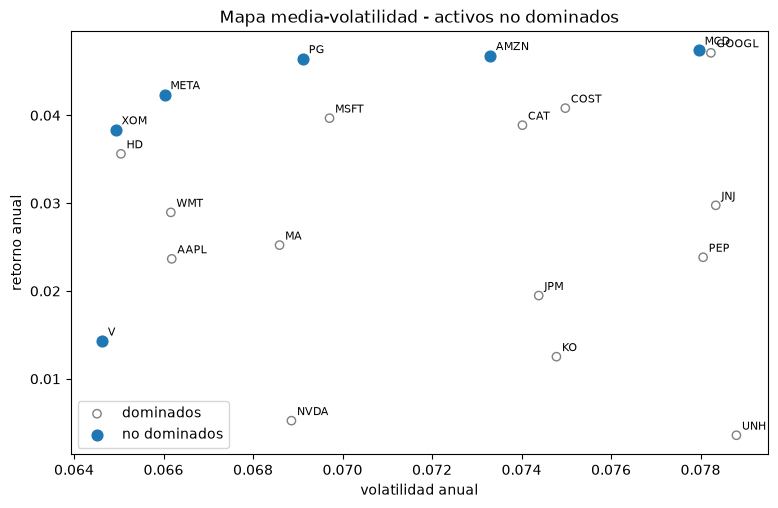

In [27]:
import matplotlib.pyplot as plt

nd = comp["non_dominated"]
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(comp.loc[~nd, "volatility_annual"], comp.loc[~nd, "mean_log_annual"],
           facecolors="none", edgecolors="gray", label="dominados")
ax.scatter(comp.loc[nd, "volatility_annual"], comp.loc[nd, "mean_log_annual"],
           color="tab:blue", s=60, label="no dominados")

for tk in comp.index:
    ax.annotate(tk, (comp.loc[tk, "volatility_annual"],
                     comp.loc[tk, "mean_log_annual"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("volatilidad anual")
ax.set_ylabel("retorno anual")
ax.set_title("Mapa media-volatilidad - activos no dominados")
ax.legend()
plt.show()

Este grafico es el borrador de lo que ira en `charts.py`, en la vista
*comparacion*. La regla se mantiene: `src/` calcula las tres columnas y no sabe
que existe un grafico; `charts.py` recibe la tabla y dibuja.